<a href="https://colab.research.google.com/github/adityab-tech/DC/blob/main/MNIST_adi.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Initial

In [ ]:
!pip install scikit-image -q

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_openml
from scipy.ndimage import rotate, shift
from sklearn.model_selection import train_test_split

from sklearn.decomposition import PCA
from skimage.feature import local_binary_pattern,hog

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score,classification_report

import warnings
warnings.filterwarnings("ignore")

In [ ]:
mnist = fetch_openml('mnist_784',version=1,as_frame=False,parser='auto')   #as_frame = false matlab return as np arr else return as pd data frame
X = mnist.data.astype(np.float32)
y = mnist.target.astype(np.int64)

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (70000, 784)
y shape: (70000,)


In [ ]:
X = X/255.0                              #Pixel values normalize from 0–255 to 0–1
X_images = X.reshape(-1,28,28)           #784 flattened pixels → 28×28 image
print(X_images.shape)

(70000, 28, 28)


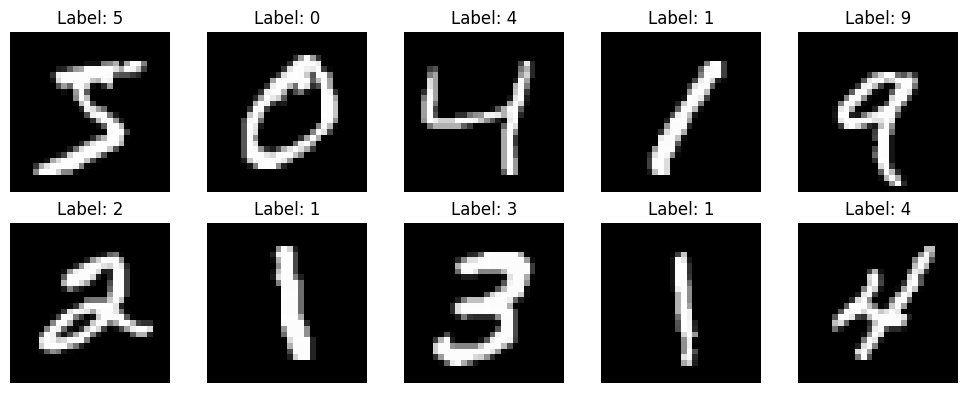

In [ ]:
fig, axes = plt.subplots(2, 5, figsize=(10, 4))
for i, ax in enumerate(axes.ravel()):               #ravel 2d axes ko 1d axes banati hai
    ax.imshow(X_images[i], cmap="gray")
    ax.set_title(f"Label: {y[i]}")
    ax.axis("off")
plt.tight_layout()
plt.show()

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X_images,y,test_size=0.2,random_state=42,stratify=y)
#stratify=y -- Ye ensure karta hai ki train aur test dono mein digits ka class distribution approx same rahe
print("Training:", X_train.shape)
print("Testing :", X_test.shape)

Training: (56000, 28, 28)
Testing : (14000, 28, 28)


In [ ]:
def augment_rotation(images, labels, angle=15):
    augmented_images = []
    augmented_labels = []

    for img, label in zip(images, labels):
      #Agar reshape=True hota, toh rotated image ko poora fit karne ke liye output dimensions change ho sakte the.
        aug_img = rotate(img,angle=angle,reshape=False,mode='constant',cval=0)
        augmented_images.append(aug_img)
        augmented_labels.append(label)

    return np.array(augmented_images), np.array(augmented_labels)

In [ ]:
def augment_shift(images, labels, shift_pixels=2):
    augmented_images = []
    augmented_labels = []

    for img, label in zip(images, labels):
      #humne shift=() yeh dekar x and y dono axis pe 2,2 ka shift bola hai
      # mode='constant' --Jab image shift hoti hai, kuch pixels original image ke boundary se bahar chale jaate hain. toh unhe fixed value(0) se bharo
        aug_img = shift(img,shift=(shift_pixels, shift_pixels),mode='constant',cval=0)
        augmented_images.append(aug_img)
        augmented_labels.append(label)

    return np.array(augmented_images), np.array(augmented_labels)

In [ ]:
AUG_SIZE = 10000
X_aug_base = X_train[:AUG_SIZE]
y_aug_base = y_train[:AUG_SIZE]
#hum aug mai har data ko 2 ways se kar rahe hai ek jisme 15 deg rot hoga and ek mai 2 pixel shifted value hogi taaki model sirf center ki bajaye har jagah focus karna seekhe
X_rot, y_rot = augment_rotation(X_aug_base,y_aug_base,angle=15)
X_shift, y_shift = augment_shift( X_aug_base, y_aug_base, shift_pixels=2)

print(X_rot.shape)
print(X_shift.shape)

(10000, 28, 28)
(10000, 28, 28)


In [ ]:
X_train_aug = np.concatenate([X_train,X_rot,X_shift])
y_train_aug = np.concatenate([y_train,y_rot,y_shift])

print("Original training:", X_train.shape)
print("Augmented training:", X_train_aug.shape)

Original training: (56000, 28, 28)
Augmented training: (76000, 28, 28)


In [ ]:
#hum 28×28 ki img ko 784-dimensional vectors mein convert kar rahe hain.
#-1 Python khud calculate kar le ki second dimension kitna hona chahiye
X_train_flat = X_train_aug.reshape(len(X_train_aug), -1)
X_test_flat = X_test.reshape(len(X_test), -1)

print(X_train_flat.shape)
print(X_test_flat.shape)

(76000, 784)
(14000, 784)


#ML

In [ ]:
#solver = model ko train karne ka optimization method
#n jobs=-1 -- available CPU cores ko maximum use karo.
logistic_raw = LogisticRegression(max_iter=100,solver='lbfgs',n_jobs=-1)
logistic_raw.fit(X_train_flat, y_train_aug)
y_pred = logistic_raw.predict(X_test_flat)
accuracy = accuracy_score(y_test, y_pred)

print("Raw Pixel Logistic Regression Accuracy:",accuracy)

Raw Pixel Logistic Regression Accuracy: 0.9031428571428571


In [ ]:
#pca for feature extraction
pca = PCA(n_components=100,random_state=42)
X_train_pca = pca.fit_transform(X_train_flat)
X_test_pca = pca.transform(X_test_flat)

print("Original features:", X_train_flat.shape[1])
print("PCA features:", X_train_pca.shape[1])

Original features: 784
PCA features: 100


In [ ]:
explained_variance = np.sum(pca.explained_variance_ratio_)
print("Variance retained:",explained_variance)

Variance retained: 0.91238153


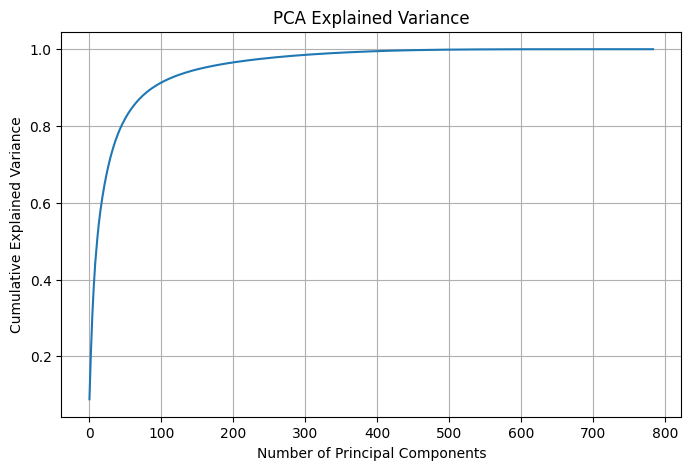

In [ ]:
pca_full = PCA().fit(X_train_flat)
cumulative_variance = np.cumsum(pca_full.explained_variance_ratio_)
plt.figure(figsize=(8, 5))
plt.plot(cumulative_variance)

plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("PCA Explained Variance")

plt.grid()
plt.show()

In [ ]:
logistic_pca = LogisticRegression(max_iter=100,solver='lbfgs',n_jobs=-1)
#nga just read about lbfgs optimization methoda
logistic_pca.fit(X_train_pca,y_train_aug)
y_pred_pca = logistic_pca.predict(X_test_pca)
accuracy_pca = accuracy_score(y_test,y_pred_pca)

print("PCA + Logistic Regression Accuracy:",accuracy_pca)

PCA + Logistic Regression Accuracy: 0.8987857142857143


In [ ]:
rf_pca = RandomForestClassifier(n_estimators=100,random_state=42,n_jobs=-1)
rf_pca.fit(X_train_pca,y_train_aug)
y_pred_rf_pca = rf_pca.predict(X_test_pca)
accuracy_rf_pca = accuracy_score(y_test,y_pred_rf_pca)

print("PCA + Random Forest Accuracy:",accuracy_rf_pca)

PCA + Random Forest Accuracy: 0.9527857142857142


In [ ]:
#p=8 -- har pixel ke around 8 neighboring points consider karega
#r=1--neighbors ka radius 1 pixel
def extract_lbp_features(images, P=8, R=1):
    features = []

    for img in images:
        lbp = local_binary_pattern(img,P,R,method='uniform')
        #hist → har LBP pattern kitni baar aaya, uski count & _ → histogram ke bin edges ko ignore kar rahe hain
        hist, _ = np.histogram(lbp.ravel(),bins=np.arange(0, P + 3),range=(0, P + 2))
        hist = hist.astype("float")
        hist /= (hist.sum() + 1e-6)
        features.append(hist)

    return np.array(features)

In [ ]:
X_train_lbp = extract_lbp_features(X_train_aug)
X_test_lbp = extract_lbp_features(X_test)

print("LBP train shape:", X_train_lbp.shape)
print("LBP test shape :", X_test_lbp.shape)

LBP train shape: (76000, 10)
LBP test shape : (14000, 10)


In [ ]:
rf_lbp = RandomForestClassifier(n_estimators=100,random_state=42,n_jobs=-1)
rf_lbp.fit(X_train_lbp,y_train_aug)
y_pred_lbp = rf_lbp.predict(X_test_lbp)
accuracy_lbp = accuracy_score(y_test,y_pred_lbp)

print("LBP + Random Forest Accuracy:",accuracy_lbp)

LBP + Random Forest Accuracy: 0.4295


In [ ]:
def extract_hog_features(images):
    features = []

    for img in images:
      #orientations=9 → gradient directions ko 9 orientation bins mein divide karega. block_norm='L2-Hys' → HOG features ko L2-Hys normalization se normalize karega.
        hog_feature = hog(img,orientations=9,pixels_per_cell=(4, 4),cells_per_block=(2, 2),block_norm='L2-Hys')
        features.append(hog_feature)
    return np.array(features)

In [ ]:
X_train_hog = extract_hog_features(X_train_aug)
X_test_hog = extract_hog_features(X_test)

print("HOG train shape:", X_train_hog.shape)
print("HOG test shape :", X_test_hog.shape)

HOG train shape: (76000, 1296)
HOG test shape : (14000, 1296)


In [ ]:
rf_hog = RandomForestClassifier(n_estimators=100,random_state=42,n_jobs=-1)
rf_hog.fit(X_train_hog,y_train_aug)
y_pred_hog = rf_hog.predict(X_test_hog)
accuracy_hog = accuracy_score(y_test,y_pred_hog)

print("HOG + Random Forest Accuracy:",accuracy_hog)

HOG + Random Forest Accuracy: 0.9737142857142858


In [ ]:
logistic_hog = LogisticRegression(max_iter=200,solver='lbfgs',n_jobs=-1)
logistic_hog.fit(X_train_hog,y_train_aug)
y_pred_hog_lr = logistic_hog.predict(X_test_hog)
accuracy_hog_lr = accuracy_score(y_test,y_pred_hog_lr)

print("HOG + Logistic Regression Accuracy:",accuracy_hog_lr)

HOG + Logistic Regression Accuracy: 0.9795714285714285


In [ ]:
results = pd.DataFrame({
    "Feature": ["Raw Pixels","PCA","PCA","LBP","HOG","HOG",],
    "Classifier": ["Logistic Regression","Logistic Regression","Random Forest","Random Forest","Random Forest","Logistic Regression",],
    "Accuracy": [accuracy,accuracy_pca,accuracy_rf_pca,accuracy_lbp,accuracy_hog,accuracy_hog_lr,]
})
results = results.sort_values("Accuracy",ascending=False)
results

,Feature,Classifier,Accuracy
5,HOG,Logistic Regression,0.979571
4,HOG,Random Forest,0.973714
2,PCA,Random Forest,0.952786
0,Raw Pixels,Logistic Regression,0.903143
1,PCA,Logistic Regression,0.898786
3,LBP,Random Forest,0.429500


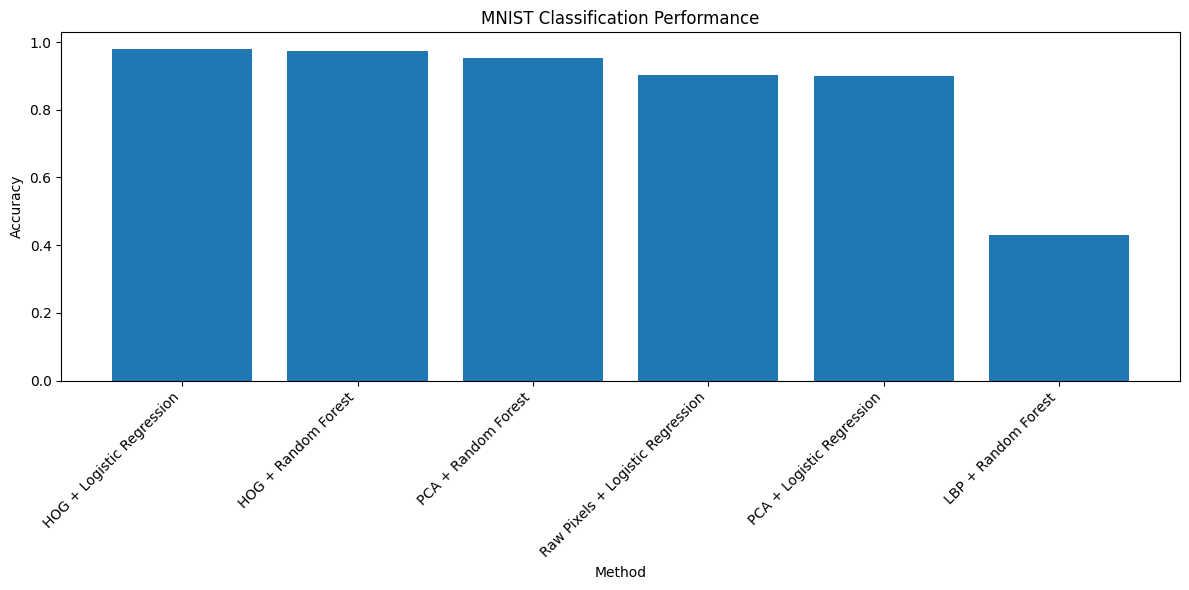

In [ ]:
plt.figure(figsize=(12, 6))
labels = (results["Feature"]+ " + "+ results["Classifier"])
plt.bar(labels,results["Accuracy"])

plt.ylabel("Accuracy")
plt.xlabel("Method")
plt.title("MNIST Classification Performance")

plt.xticks(rotation=45,ha="right")
plt.tight_layout()
plt.show()

In [ ]:
print(classification_report(y_test,y_pred_hog))

              precision    recall  f1-score   support

           0       0.98      0.99      0.98      1381
           1       0.98      0.98      0.98      1575
           2       0.97      0.98      0.97      1398
           3       0.95      0.97      0.96      1428
           4       0.97      0.97      0.97      1365
           5       0.98      0.97      0.97      1263
           6       0.98      0.98      0.98      1375
           7       0.97      0.98      0.98      1459
           8       0.98      0.96      0.97      1365
           9       0.97      0.95      0.96      1391

    accuracy                           0.97     14000
   macro avg       0.97      0.97      0.97     14000
weighted avg       0.97      0.97      0.97     14000



#CNN

In [ ]:
X_train_cnn = X_train_aug.reshape(-1, 28, 28, 1).astype(np.float32)
X_test_cnn = X_test.reshape(-1, 28, 28, 1).astype(np.float32)
print(X_train_cnn.shape)
print(X_test_cnn.shape)

(76000, 28, 28, 1)
(14000, 28, 28, 1)


In [ ]:
from tensorflow.keras import layers, models

cnn = models.Sequential([
    layers.Input(shape=(28, 28, 1)),
    layers.Conv2D(32, (3, 3), activation='relu'),           #32 filters and 3x3 ka kernel
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),                            #feature maps ka size reduce karta hai
    layers.Flatten(),
    layers.Dropout(0.3),
    layers.Dense(128, activation='relu'),
    layers.Dense(10, activation='softmax')
])

cnn.compile(optimizer='adamW',loss='sparse_categorical_crossentropy',metrics=['accuracy'])

In [ ]:
cnn_train = cnn.fit(X_train_cnn, y_train_aug,validation_split=0.1,epochs=10,batch_size=128)

Epoch 1/10
535/535 ━━━━━━━━━━━━━━━━━━━━ 10s 10ms/step - accuracy: 0.9311 - loss: 0.2296 - val_accuracy: 0.9122 - val_loss: 0.2813
Epoch 2/10
535/535 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.9778 - loss: 0.0731 - val_accuracy: 0.9417 - val_loss: 0.1838
Epoch 3/10
535/535 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.9841 - loss: 0.0513 - val_accuracy: 0.9545 - val_loss: 0.1472
Epoch 4/10
535/535 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9867 - loss: 0.0421 - val_accuracy: 0.9638 - val_loss: 0.1116
Epoch 5/10
535/535 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9887 - loss: 0.0339 - val_accuracy: 0.9676 - val_loss: 0.1016
Epoch 6/10
535/535 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9909 - loss: 0.0284 - val_accuracy: 0.9728 - val_loss: 0.0918
Epoch 7/10
535/535 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9923 - loss: 0.0235 - val_accuracy: 0.9700 - val_loss: 0.0943
Epoch 8/10
535/535 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.9933 - loss: 0.0203 - val_accuracy: 

In [ ]:
test_loss, accuracy_cnn = cnn.evaluate(X_test_cnn, y_test)
print("CNN Accuracy:", accuracy_cnn)

438/438 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9919 - loss: 0.0261
CNN Accuracy: 0.9919285774230957


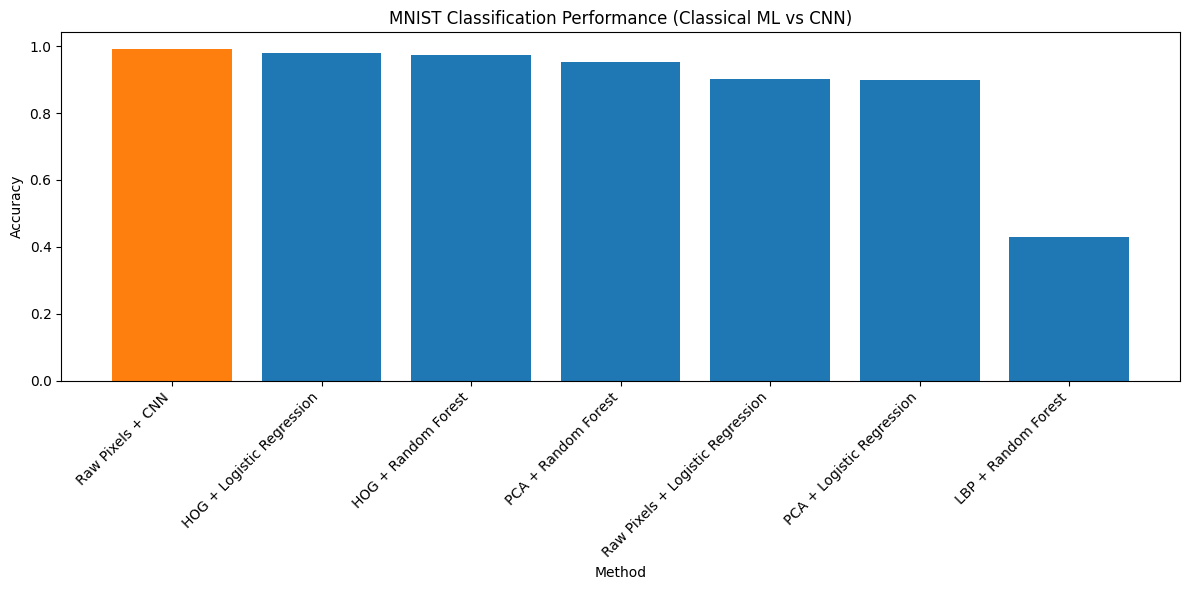

In [ ]:
results = pd.DataFrame({
    "Feature": ["Raw Pixels", "PCA", "PCA", "LBP", "HOG", "HOG", "Raw Pixels"],
    "Classifier": ["Logistic Regression", "Logistic Regression", "Random Forest",
                   "Random Forest", "Random Forest", "Logistic Regression", "CNN"],
    "Accuracy": [accuracy, accuracy_pca, accuracy_rf_pca, accuracy_lbp,
                 accuracy_hog, accuracy_hog_lr, accuracy_cnn]
})
results = results.sort_values("Accuracy", ascending=False)

plt.figure(figsize=(12, 6))
labels = (results["Feature"] + " + " + results["Classifier"])
colors = ["#ff7f0e" if clf == "CNN" else "#1f77b4" for clf in results["Classifier"]]
plt.bar(labels, results["Accuracy"], color=colors)

plt.ylabel("Accuracy")
plt.xlabel("Method")
plt.title("MNIST Classification Performance (Classical ML vs CNN)")

plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()